# 1. Setup & Dependencies

This cell installs the required deep learning and visualization libraries, specifically **TensorFlow** (the framework that powers MobileNetV2). It also imports essential Python modules for computer vision ( `cv2` , `PIL` ), matrix operations ( `numpy` ), data visualization ( `matplotlib` , `seaborn` ), and file management necessary for processing our datasets. *Note: The `--quiet` flag ensures a clean installation output.*

In [32]:
!pip install tensorflow matplotlib seaborn scikit-learn pyyaml --quiet

import os, yaml, shutil, zipfile, glob, random, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import tensorflow as tf
import cv2
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

warnings.filterwarnings('ignore')
print('✅ Dependencies loaded.')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

✅ Dependencies loaded.
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Configuration & Global Class Mapping

This cell defines the core parameters of the project, specifically for **MobileNetV2** (the architecture powering our image classification). It establishes the list of supported fruits and their target ripeness stages to generate a Unified Global Class Map. It also sets essential deep learning hyperparameters for model training (`ALPHA`, `IMG_SIZE`, `BATCH_SIZE`), phase-specific learning rates (`LR_HEAD`, `LR_FINETUNE`), and color codes necessary for visualizing our predictions (`FRUIT_COLORS`). *Note: The `EPOCHS_FROZEN` and `EPOCHS_FINETUNE` variables control the two-stage transfer learning process.*

In [33]:
FRUITS    = ['Avocado', 'Guava', 'Mango', 'Pineapple', 'Banana']
RIPENESS  = ['Overripe', 'Ripe', 'Unripe']
CLASS_NAMES = [f'{f}_{r}' for f in FRUITS for r in RIPENESS]
NUM_CLASSES  = len(CLASS_NAMES)   # 15

# MobileNetV2 α=1.0 config
ALPHA          = 1.0
IMG_SIZE       = 224
BATCH_SIZE     = 32
EPOCHS_FROZEN  = 10   # Train head only
EPOCHS_FINETUNE= 40   # Unfreeze & fine-tune
LR_HEAD        = 1e-3
LR_FINETUNE    = 1e-5
PATIENCE       = 10
VAL_RATIO      = 0.15
TEST_RATIO     = 0.10

FRUIT_COLORS = {
    'Avocado':'#2ECC71','Guava':'#E74C3C',
    'Mango':'#F39C12','Pineapple':'#F1C40F','Banana':'#F4D35E'
}

print('=== GLOBAL CLASS MAP ===')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d}: {name}')
print(f'\nMobileNetV2 alpha = {ALPHA}')

=== GLOBAL CLASS MAP ===
   0: Avocado_Overripe
   1: Avocado_Ripe
   2: Avocado_Unripe
   3: Guava_Overripe
   4: Guava_Ripe
   5: Guava_Unripe
   6: Mango_Overripe
   7: Mango_Ripe
   8: Mango_Unripe
   9: Pineapple_Overripe
  10: Pineapple_Ripe
  11: Pineapple_Unripe
  12: Banana_Overripe
  13: Banana_Ripe
  14: Banana_Unripe

MobileNetV2 alpha = 1.0


# 3. Storage Mounting & Path Verification

Because Colab environments are temporary, we must mount our Google Drive to access our persistent fruit datasets and save our trained models. This cell defines the exact paths to our individual fruit datasets ( `ZIP_PATHS` ). It creates dedicated output directories for our merged datasets, the specific Keras-compatible folder structure required by MobileNetV2 ( `CLF_DIR` ), and model weights. Finally, it includes a built-in Path Checker that immediately verifies if the files exist, preventing "File Not Found" errors later in the pipeline.

In [34]:
drive.mount('/content/drive')

ZIP_PATHS = [
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Avocado',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Mango',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Pineapple',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Guava',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Banana',
]

DATASET_DIR  = '/content/merged_dataset'
CLF_DIR      = '/content/clf_dataset'   # Keras folder structure
MODEL_DIR    = '/content/drive/MyDrive/DEEP LEARNING/YOLO26/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('\n🔍 Checking paths...')
for p in ZIP_PATHS:
    status = '✅' if os.path.exists(p) else '❌'
    print(f'  {status} {p}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Checking paths...
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Avocado
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Mango
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Pineapple
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Guava
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Banana


# 4. Automated Dataset Integration & Cleaning

This cell serves as the initial preprocessing engine for the dataset. It extracts each raw fruit dataset and reads the internal `data.yaml` to identify the local class order. It then translates these local IDs into our Unified Global Class Map, validates every image-label pair, and consolidates the clean data into a unified merged directory. Corrupted images, missing label files, or invalid class IDs are automatically skipped to ensure data integrity before converting to the final classification structure.


In [35]:
def integrate_datasets(zip_paths, output_dir, class_names, fruits, ripeness):
    for split in ['train', 'valid', 'test']:
        os.makedirs(f'{output_dir}/{split}/images', exist_ok=True)
        os.makedirs(f'{output_dir}/{split}/labels', exist_ok=True)

    stats  = {n: 0 for n in class_names}
    errors = []

    for zip_path in zip_paths:
        fruit = Path(zip_path).stem.split('.')[0]
        print(f"\n{'─'*55}\nProcessing: {fruit}")
        tmp = f'/content/tmp_{fruit}'
        if os.path.exists(tmp): shutil.rmtree(tmp)

        if os.path.isdir(zip_path):
            shutil.copytree(zip_path, tmp)
        else:
            try:
                with zipfile.ZipFile(zip_path, 'r') as z: z.extractall(tmp)
            except Exception as e:
                errors.append(f'{fruit}: {e}'); continue

        yaml_candidates = glob.glob(f'{tmp}/**/*.yaml', recursive=True)
        local_classes = None
        for yp in yaml_candidates:
            with open(yp) as f: d = yaml.safe_load(f)
            if 'names' in d:
                local_classes = d['names']
                print(f'  ✅ data.yaml: {local_classes}'); break

        if local_classes is None:
            local_classes = [f'{fruit}_{r}' for r in ripeness]
            print(f'  ☐  No yaml, assuming: {local_classes}')

        local_to_global = {}
        for lid, lname in enumerate(local_classes):
            full = lname if fruit.lower() in lname.lower() else f'{fruit}_{lname}'
            if full in class_names:
                local_to_global[lid] = class_names.index(full)
            else:
                errors.append(f"{fruit}: '{full}' not in CLASS_NAMES")

        for split in ['train', 'valid', 'test', '']:
            base_split = os.path.join(tmp, split) if split else tmp
            src_img = os.path.join(base_split, 'images')
            src_lbl = os.path.join(base_split, 'labels')
            if not os.path.exists(src_img): continue

            ok, skip = 0, 0
            for img_file in os.listdir(src_img):
                if not img_file.lower().endswith(('.jpg','.jpeg','.png')): continue
                stem     = Path(img_file).stem
                lbl_path = os.path.join(src_lbl, stem + '.txt')
                if not os.path.exists(lbl_path): skip += 1; continue

                new_lines, valid = [], True
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5: continue
                        lid = int(parts[0])
                        if lid not in local_to_global: valid = False; break
                        gid = local_to_global[lid]
                        new_lines.append(f"{gid} {' '.join(parts[1:])}")

                if not valid: skip += 1; continue
                target_split = split if split else 'train'
                dst_img = f'{output_dir}/{target_split}/images/{fruit}_{img_file}'
                dst_lbl = f'{output_dir}/{target_split}/labels/{fruit}_{stem}.txt'
                shutil.copy2(os.path.join(src_img, img_file), dst_img)
                with open(dst_lbl, 'w') as f: f.write('\n'.join(new_lines))
                stats[class_names[gid]] += 1
                ok += 1

            if ok > 0: print(f'  [{split or "root"}] ✅ {ok} | ☐ {skip} skipped')

        shutil.rmtree(tmp)

    print(f"\nIntegration complete. Errors: {len(errors)}")
    return stats, errors

if os.path.exists(DATASET_DIR): shutil.rmtree(DATASET_DIR)
stats, errors = integrate_datasets(ZIP_PATHS, DATASET_DIR, CLASS_NAMES, FRUITS, RIPENESS)


───────────────────────────────────────────────────────
Processing: Avocado
  ✅ data.yaml: ['Avocado_Overripe', 'Avocado_Ripe', 'Avocado_Unripe']
  [train] ✅ 907 | ☐ 56 skipped

───────────────────────────────────────────────────────
Processing: Mango
  ✅ data.yaml: ['Mango_Overripe', 'Mango_Ripe', 'Mango_Unripe']
  [train] ✅ 980 | ☐ 75 skipped

───────────────────────────────────────────────────────
Processing: Pineapple
  ✅ data.yaml: ['Pineapple_Overripe', 'Pineapple_Ripe', 'Pineapple_Unripe']
  [train] ✅ 530 | ☐ 31 skipped

───────────────────────────────────────────────────────
Processing: Guava
  ✅ data.yaml: ['Guava_Overripe', 'Guava_Ripe', 'Guava_Unripe']
  [train] ✅ 893 | ☐ 50 skipped

───────────────────────────────────────────────────────
Processing: Banana
  ✅ data.yaml: ['Banana_Overripe', 'Banana_Ripe', 'Banana_Unripe']
  [train] ✅ 4221 | ☐ 0 skipped

Integration complete. Errors: 0


# 5. Automated Dataset Splitting (Train / Val / Test)

Deep learning models strictly require a Validation Set to evaluate performance and prevent overfitting during training, as well as a Test Set for final evaluation. Because the initial merged dataset only contains a training folder, this script shuffles the unified data and randomly allocates 15% to the Validation set and 10% to the Test set. It ensures that both the images and their corresponding label files are accurately moved into their respective directories before we convert them to the final Keras format.

In [36]:
def create_splits(base_dir, val_ratio=0.15, test_ratio=0.10):
    train_img = f'{base_dir}/train/images'
    train_lbl = f'{base_dir}/train/labels'
    files = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(files)
    n_val  = int(len(files) * val_ratio)
    n_test = int(len(files) * test_ratio)
    for sname, sfiles in [('valid', files[:n_val]), ('test', files[n_val:n_val+n_test])]:
        print(f'📁 {sname}: {len(sfiles)} files')
        for f in sfiles:
            stem = os.path.splitext(f)[0]
            shutil.move(f'{train_img}/{f}', f'{base_dir}/{sname}/images/{f}')
            lp = f'{train_lbl}/{stem}.txt'
            if os.path.exists(lp):
                shutil.move(lp, f'{base_dir}/{sname}/labels/{stem}.txt')

create_splits(DATASET_DIR)

📁 valid: 1087 files
📁 test: 724 files


# 6. Conversion: YOLO Format to Keras Folder Structure

While YOLO models are designed to read `.txt` files containing bounding box coordinates (Object Detection), MobileNetV2 requires a different approach (Image Classification). It cannot read `.txt` files; it strictly requires images to be sorted into physical folders named after their class.

This cell acts as a data bridge. It reads the original YOLO dataset, uses the coordinate data to physically crop every single fruit out of the larger image, resizes the crop to `224x224` pixels, and saves it into the correct class folder. It also includes an automatic filter to delete tiny corrupted images (smaller than 15x15 pixels) to prevent model distortion.

In [39]:
def yolo_dataset_to_clf(yolo_dir, clf_dir, class_names, img_size=224):
    """
    Converts YOLO-format dataset to Keras ImageDataGenerator folder structure.
    Crops each bounding box → saves as individual class-labelled image.
    Structure: clf_dir/split/ClassName/image.jpg
    """
    if os.path.exists(clf_dir): shutil.rmtree(clf_dir)

    counts = {s: {c: 0 for c in class_names} for s in ['train','valid','test']}

    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(yolo_dir, split, 'images')
        lbl_dir = os.path.join(yolo_dir, split, 'labels')
        if not os.path.exists(img_dir): continue

        for cls in class_names:
            os.makedirs(os.path.join(clf_dir, split, cls), exist_ok=True)

        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith(('.jpg','.jpeg','.png')): continue
            stem = Path(img_file).stem
            lbl_path = os.path.join(lbl_dir, stem + '.txt')
            img_path = os.path.join(img_dir, img_file)

            img = Image.open(img_path).convert('RGB')
            W, H = img.size

            if not os.path.exists(lbl_path):
                continue

            with open(lbl_path) as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                x1 = int((cx - bw/2) * W)
                y1 = int((cy - bh/2) * H)
                x2 = int((cx + bw/2) * W)
                y2 = int((cy + bh/2) * H)
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(W,x2), min(H,y2)

                if x2 <= x1 or y2 <= y1: continue

                crop = img.crop((x1,y1,x2,y2)).resize((img_size, img_size))
                cls_name = class_names[cls_id]
                out_path = os.path.join(clf_dir, split, cls_name, f'{stem}_{idx}.jpg')
                crop.save(out_path, 'JPEG', quality=90)
                counts[split][cls_name] += 1

    print('\n=== CLF DATASET SUMMARY ===')
    for split in ['train','valid','test']:
        total = sum(counts[split].values())
        print(f'\n  {split.upper()} — {total} crops')
        for cls in class_names:
            print(f'    {cls:25s}: {counts[split][cls]}')
    return counts

clf_counts = yolo_dataset_to_clf(DATASET_DIR, CLF_DIR, CLASS_NAMES, IMG_SIZE)
print('\n✅ CLF dataset ready at', CLF_DIR)


=== CLF DATASET SUMMARY ===

  TRAIN — 14454 crops
    Avocado_Overripe         : 225
    Avocado_Ripe             : 231
    Avocado_Unripe           : 227
    Guava_Overripe           : 329
    Guava_Ripe               : 417
    Guava_Unripe             : 504
    Mango_Overripe           : 1437
    Mango_Ripe               : 3207
    Mango_Unripe             : 4557
    Pineapple_Overripe       : 202
    Pineapple_Ripe           : 92
    Pineapple_Unripe         : 120
    Banana_Overripe          : 1232
    Banana_Ripe              : 1069
    Banana_Unripe            : 605

  VALID — 1923 crops
    Avocado_Overripe         : 44
    Avocado_Ripe             : 44
    Avocado_Unripe           : 47
    Guava_Overripe           : 75
    Guava_Ripe               : 86
    Guava_Unripe             : 94
    Mango_Overripe           : 226
    Mango_Ripe               : 491
    Mango_Unripe             : 144
    Pineapple_Overripe       : 40
    Pineapple_Ripe           : 13
    Pineapple_Unripe

# 7. Data Augmentation & Generator Setup

This cell configures the data pipelines required to feed images into MobileNetV2. It utilizes Keras' `ImageDataGenerator` to automatically load images from our newly created class folders. Crucially, it applies Data Augmentation (random rotations, shifts, zooms, and flips) exclusively to the training set. This artificially expands the dataset and prevents the model from memorizing exact images (overfitting). All images are also mathematically scaled down to values between 0 and 1 (`rescale=1./255`), which is a strict requirement for neural network processing.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f'\nTrain: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}')

Found 14478 images belonging to 15 classes.
Found 1877 images belonging to 15 classes.
Found 1274 images belonging to 15 classes.

Train: 14478 | Val: 1877 | Test: 1274


# 8. Model Architecture (MobileNetV2)

This cell defines the core neural network architecture utilizing transfer learning. It loads a pre-trained MobileNetV2 base model using ImageNet weights and explicitly freezes its internal layers so they are not altered during the initial training phase. On top of this frozen base, a custom classification "head" is constructed, consisting of Global Average Pooling, Batch Normalization, and Dense layers paired with Dropout to actively prevent overfitting. The final output is a Softmax layer mathematically structured to predict exact probabilities across our 15 custom fruit ripeness classes.

In [ ]:
def build_mobilenetv2(alpha, num_classes, img_size=224):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        alpha=alpha,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # Frozen for phase 1

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base_model = build_mobilenetv2(ALPHA, NUM_CLASSES, IMG_SIZE)
model.summary()

trainable = sum(1 for l in model.layers if l.trainable)
total     = len(model.layers)
print(f'\nTotal layers: {total} | Trainable (head only): {trainable}')
print(f'Total params: {model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,625,871 (10.02 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Total layers: 161 | Trainable (head only): 7
Total params: 2,625,871


# 9. Phase 1 Training: Classification Head

This cell initiates the first phase of the transfer learning process. It compiles the model using the Adam optimizer and Categorical Crossentropy loss, tracking both standard and Top-3 accuracy. Crucially, it establishes three automated callbacks: Early Stopping (to halt training if validation accuracy plateaus and prevent overfitting), Learning Rate Reduction (to make finer parameter adjustments when learning stalls), and Model Checkpointing (to automatically save the best-performing weights). Finally, it executes the training loop exclusively on the custom classification head while the base MobileNetV2 layers remain completely frozen.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint('/content/best_head_10.keras', save_best_only=True, monitor='val_accuracy'),
]

print('=== PHASE 1: Training classification head (α=1.0) ===')
history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)
print('✅ Phase 1 complete')

=== PHASE 1: Training classification head (α=1.0) ===
Epoch 1/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 319s 652ms/step - accuracy: 0.8171 - loss: 0.5400 - top3_acc: 0.9530 - val_accuracy: 0.8418 - val_loss: 0.4113 - val_top3_acc: 0.9872 - learning_rate: 0.0010
Epoch 2/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 240s 529ms/step - accuracy: 0.8809 - loss: 0.3270 - top3_acc: 0.9856 - val_accuracy: 0.8839 - val_loss: 0.3185 - val_top3_acc: 0.9936 - learning_rate: 0.0010
Epoch 3/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 239s 528ms/step - accuracy: 0.8970 - loss: 0.2819 - top3_acc: 0.9894 - val_accuracy: 0.8801 - val_loss: 0.2934 - val_top3_acc: 0.9952 - learning_rate: 0.0010
Epoch 4/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 237s 522ms/step - accuracy: 0.9067 - loss: 0.2566 - top3_acc: 0.9932 - val_accuracy: 0.8791 - val_loss: 0.3044 - val_top3_acc: 0.9936 - learning_rate: 0.0010
Epoch 5/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 236s 520ms/step - accuracy: 0.9122 - loss: 0.2388 - top3_acc: 0.9927 - val_accuracy: 0.8876 - val_loss: 0.2977 - v

# 10. Phase 2: Fine-Tuning the Base Model

This cell executes the second stage of transfer learning. It unfreezes the top 30 layers of the pre-trained MobileNetV2 base model while keeping the foundational layers completely frozen. The model is recompiled with a significantly lower learning rate (`LR_FINETUNE`) to allow for highly precise weight adjustments tailored to our fruit dataset without destroying the general features ImageNet already learned. Training then resumes from the exact epoch where Phase 1 concluded, utilizing updated callbacks to monitor validation accuracy and continuously save the most optimized final weights.

In [ ]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

trainable_ft = sum(1 for l in model.layers if l.trainable)
print(f'Fine-tuning {trainable_ft} layers (from layer {fine_tune_at})')

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=5, min_lr=1e-8, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint('/content/best_finetune_10.keras', save_best_only=True, monitor='val_accuracy'),
]

print('=== PHASE 2: Fine-tuning MobileNetV2 α=1.0 ===')
history2 = model.fit(
    train_gen,
    initial_epoch=len(history1.history['loss']),
    epochs=len(history1.history['loss']) + EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)
print('✅ Phase 2 complete')

Fine-tuning 37 layers (from layer 124)
=== PHASE 2: Fine-tuning MobileNetV2 α=1.0 ===
Epoch 11/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 282s 573ms/step - accuracy: 0.8903 - loss: 0.3084 - top3_acc: 0.9856 - val_accuracy: 0.8801 - val_loss: 0.3709 - val_top3_acc: 0.9952 - learning_rate: 1.0000e-05
Epoch 12/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 235s 518ms/step - accuracy: 0.9119 - loss: 0.2471 - top3_acc: 0.9914 - val_accuracy: 0.8876 - val_loss: 0.3249 - val_top3_acc: 0.9941 - learning_rate: 1.0000e-05
Epoch 13/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 235s 520ms/step - accuracy: 0.9197 - loss: 0.2190 - top3_acc: 0.9930 - val_accuracy: 0.8897 - val_loss: 0.3061 - val_top3_acc: 0.9952 - learning_rate: 1.0000e-05
Epoch 14/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 234s 518ms/step - accuracy: 0.9246 - loss: 0.1984 - top3_acc: 0.9945 - val_accuracy: 0.8908 - val_loss: 0.2850 - val_top3_acc: 0.9952 - learning_rate: 1.0000e-05
Epoch 15/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 234s 515ms/step - accuracy: 0.9273 - loss: 0.1932 - top3_acc:

# 11. Training History Visualization

This cell evaluates the model's learning progress by generating visual performance graphs. It concatenates the training history data from both Phase 1 and Phase 2 to plot continuous side-by-side learning curves for Accuracy and Loss. It also automatically draws a vertical dashed line to mark the exact epoch where the fine-tuning phase began. This visualization is critical for analyzing how the transition from a frozen base to an unfrozen base impacted the model's overall accuracy and whether any overfitting occurred.

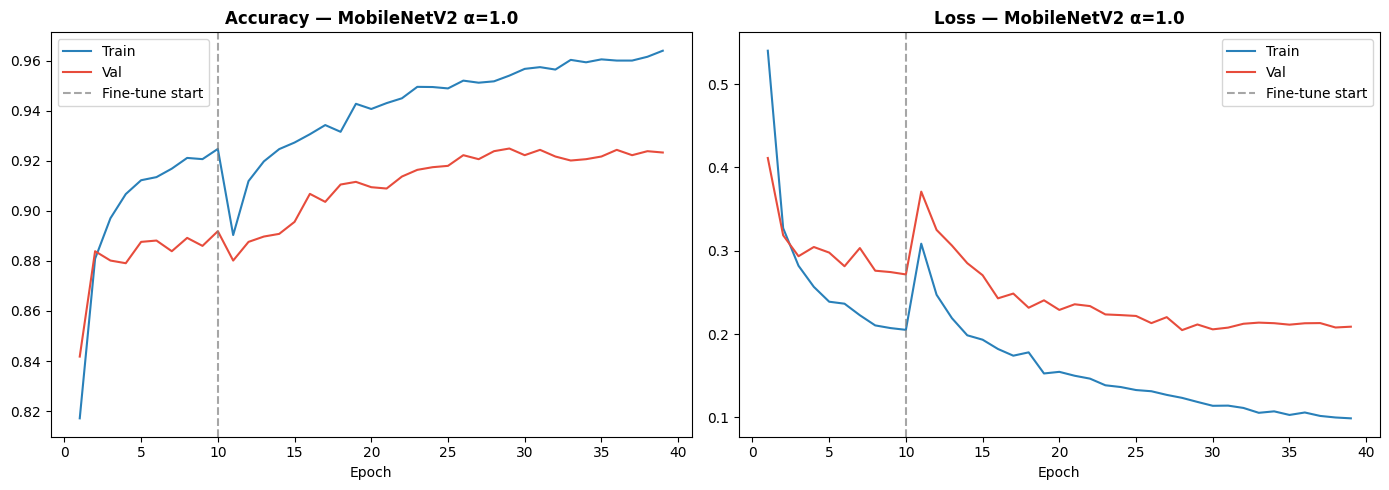

In [ ]:
def plot_history(h1, h2, alpha):
    acc  = h1.history['accuracy']        + h2.history['accuracy']
    val  = h1.history['val_accuracy']    + h2.history['val_accuracy']
    loss = h1.history['loss']            + h2.history['loss']
    vloss= h1.history['val_loss']        + h2.history['val_loss']
    ep   = range(1, len(acc)+1)
    split_ep = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train_m, val_m, title in [
        (ax1, acc,  val,   'Accuracy'),
        (ax2, loss, vloss, 'Loss')
    ]:
        ax.plot(ep, train_m, label='Train', color='#2980B9')
        ax.plot(ep, val_m,   label='Val',   color='#E74C3C')
        ax.axvline(split_ep, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(f'{title} — MobileNetV2 α={alpha}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'/content/training_history_alpha{str(alpha).replace(".","_")}.png', dpi=150)
    plt.show()

plot_history(history1, history2, ALPHA)

# 12. Model Evaluation (Test Set)

This cell executes the final performance check using the strictly isolated Test Set. It evaluates the fine-tuned MobileNetV2 model against completely unseen data to verify its real-world generalization. The script calculates and displays the Test Loss, Top-1 Test Accuracy (exact match), and Top-3 Accuracy (where the correct answer is within the top three predictions). Finally, it runs an automated diagnostic check that flags the model if the final accuracy falls below the 80% acceptable threshold.

In [ ]:
print('=== EVALUATING ON TEST SET ===')
test_loss, test_acc, test_top3 = model.evaluate(test_gen, verbose=1)
print(f'\n{"═"*45}')
print(f'  MobileNetV2 α={ALPHA}')
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Top-3 Accuracy: {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'{"═"*45}')

if test_acc < 0.80:
    print('⚠️  Accuracy < 80% — consider more data or larger model (EfficientNetB0)')
else:
    print('✅ Accuracy ≥ 80% — model performing well')

=== EVALUATING ON TEST SET ===
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 394ms/step - accuracy: 0.9105 - loss: 0.2067 - top3_acc: 1.0000

═════════════════════════════════════════════
  MobileNetV2 α=1.0
  Test Accuracy : 0.9105 (91.05%)
  Top-3 Accuracy: 1.0000 (100.00%)
  Test Loss     : 0.2067
═════════════════════════════════════════════
✅ Accuracy ≥ 80% — model performing well


# 13. Detailed Classification Report

This cell performs an in-depth statistical analysis of the model's predictive performance across every individual class. It first resets the test generator to ensure the order of predictions perfectly aligns with the true labels. It then forces the model to predict the ripeness of every image in the test set. By comparing the model's top predictions ( `y_pred` ) against the actual ground truth ( `y_true` ), it generates a comprehensive matrix detailing the Precision, Recall, and F1-Score for all 15 custom fruit classes, identifying exactly which specific fruits the model categorizes best and which ones require more training data.

In [ ]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 209ms/step

=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  Avocado_Overripe     0.6226    1.0000    0.7674        33
      Avocado_Ripe     0.9167    0.3143    0.4681        35
    Avocado_Unripe     0.8571    0.9375    0.8955        32
    Guava_Overripe     0.9592    0.9792    0.9691        48
        Guava_Ripe     0.8033    0.5568    0.6577        88
      Guava_Unripe     0.6122    0.8696    0.7186        69
    Mango_Overripe     0.9706    0.9900    0.9802       100
        Mango_Ripe     0.9874    0.9874    0.9874       318
      Mango_Unripe     1.0000    0.9908    0.9954       109
Pineapple_Overripe     1.0000    1.0000    1.0000        29
    Pineapple_Ripe     0.9231    0.8571    0.8889        14
  Pineapple_Unripe     0.8462    0.9167    0.8800        12
   Banana_Overripe     0.9441    0.9375    0.9408       144
       Banana_Ripe     0.9236    0.9416    0.9325       154
     Banana_Unripe     0.9

# 14. Confusion Matrix Visualization

This cell generates a dual-pane **Confusion Matrix** to visually diagnose the model's exact prediction errors. It cross-references the true fruit labels against the model's actual predictions. The left pane displays the raw prediction counts, while the right pane shows normalized percentages. This visual map is crucial for identifying specific misclassification patterns—such as whether the model frequently confuses a "Ripe Banana" with an "Overripe Banana"—allowing us to pinpoint exactly which classes require more training data.

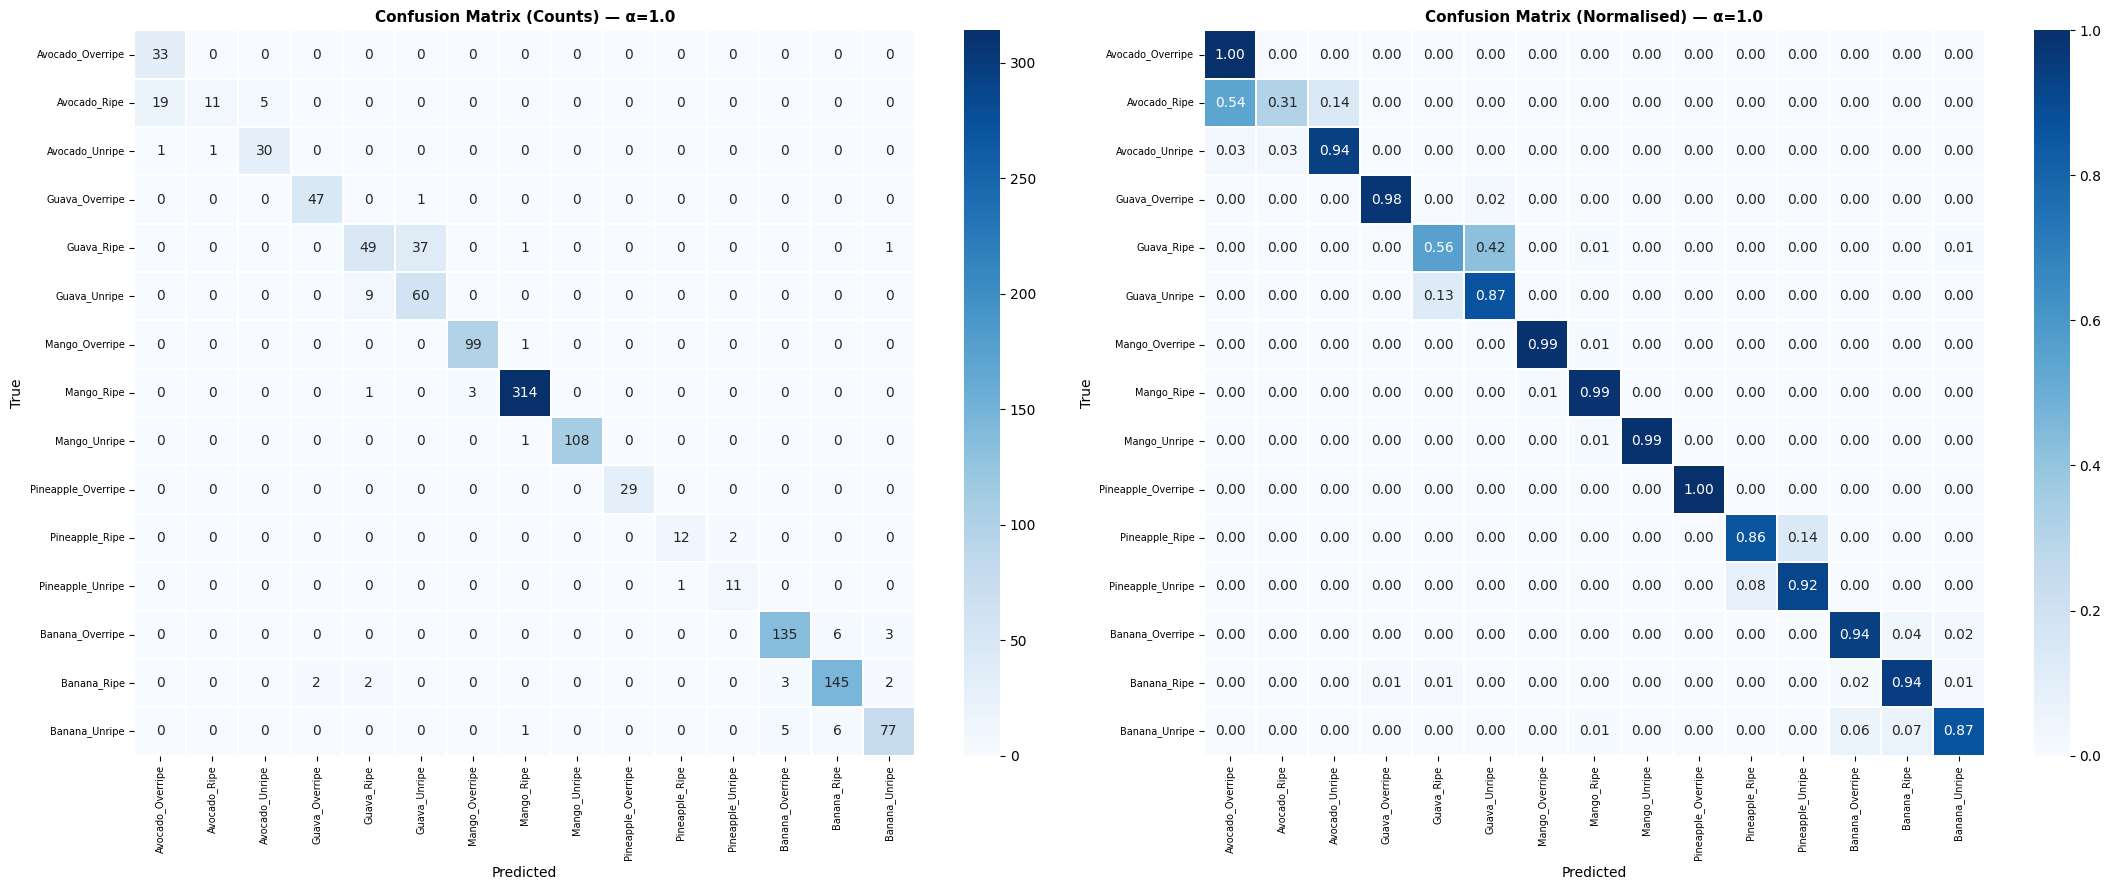

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, alpha):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, fmt, title in [
        (axes[0], cm,      'd',   'Counts'),
        (axes[1], cm_norm, '.2f', 'Normalised'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.3)
        ax.set_title(f'Confusion Matrix ({title}) — α={alpha}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='both', labelsize=7)

    plt.tight_layout()
    plt.savefig(f'/content/confusion_matrix_alpha{str(alpha).replace(".","_")}.png', dpi=150)
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, ALPHA)

# 15. Model Export & Edge Deployment (TFLite)

This cell finalizes the training pipeline by persistently saving the fully fine-tuned MobileNetV2 model ( `.keras` ) directly to your Google Drive. Furthermore, it automatically converts and compresses the model into the **TensorFlow Lite** ( `.tflite` ) format. By applying default optimizations, it significantly reduces the model's file size and memory footprint, making it fully prepared for high-speed deployment on mobile applications or edge hardware.

In [ ]:
# Save model to Drive
save_path_drive = os.path.join(MODEL_DIR, 'mobilenetv2_alpha10_fruit_ripeness.keras')
model.save(save_path_drive)
print(f'✅ Model saved → {save_path_drive}')

# Also save TFLite for edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path  = os.path.join(MODEL_DIR, 'mobilenetv2_alpha10_fruit_ripeness.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ TFLite model saved → {tflite_path}')
print(f'   TFLite size: {os.path.getsize(tflite_path)/1024:.1f} KB')

✅ Model saved → /content/drive/MyDrive/DEEP LEARNING/YOLO26/models/mobilenetv2_alpha10_fruit_ripeness.keras
Saved artifact at '/tmp/tmp1rj__vip'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  137002817183696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817184848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817185232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817184464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817183504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817185040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817185424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817186192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137002817185808: TensorSpec(shape=(), dtype=t

# 16. Inference & Grid Visualization

This cell tests the trained model by randomly selecting 15 images from the test dataset and displaying them in a visual grid. It makes a prediction for each image and compares it against the true label. To make it easy to evaluate, the text turns green if the model's prediction is correct and red if it is wrong. Finally, it saves the resulting grid as an image file for easy review.

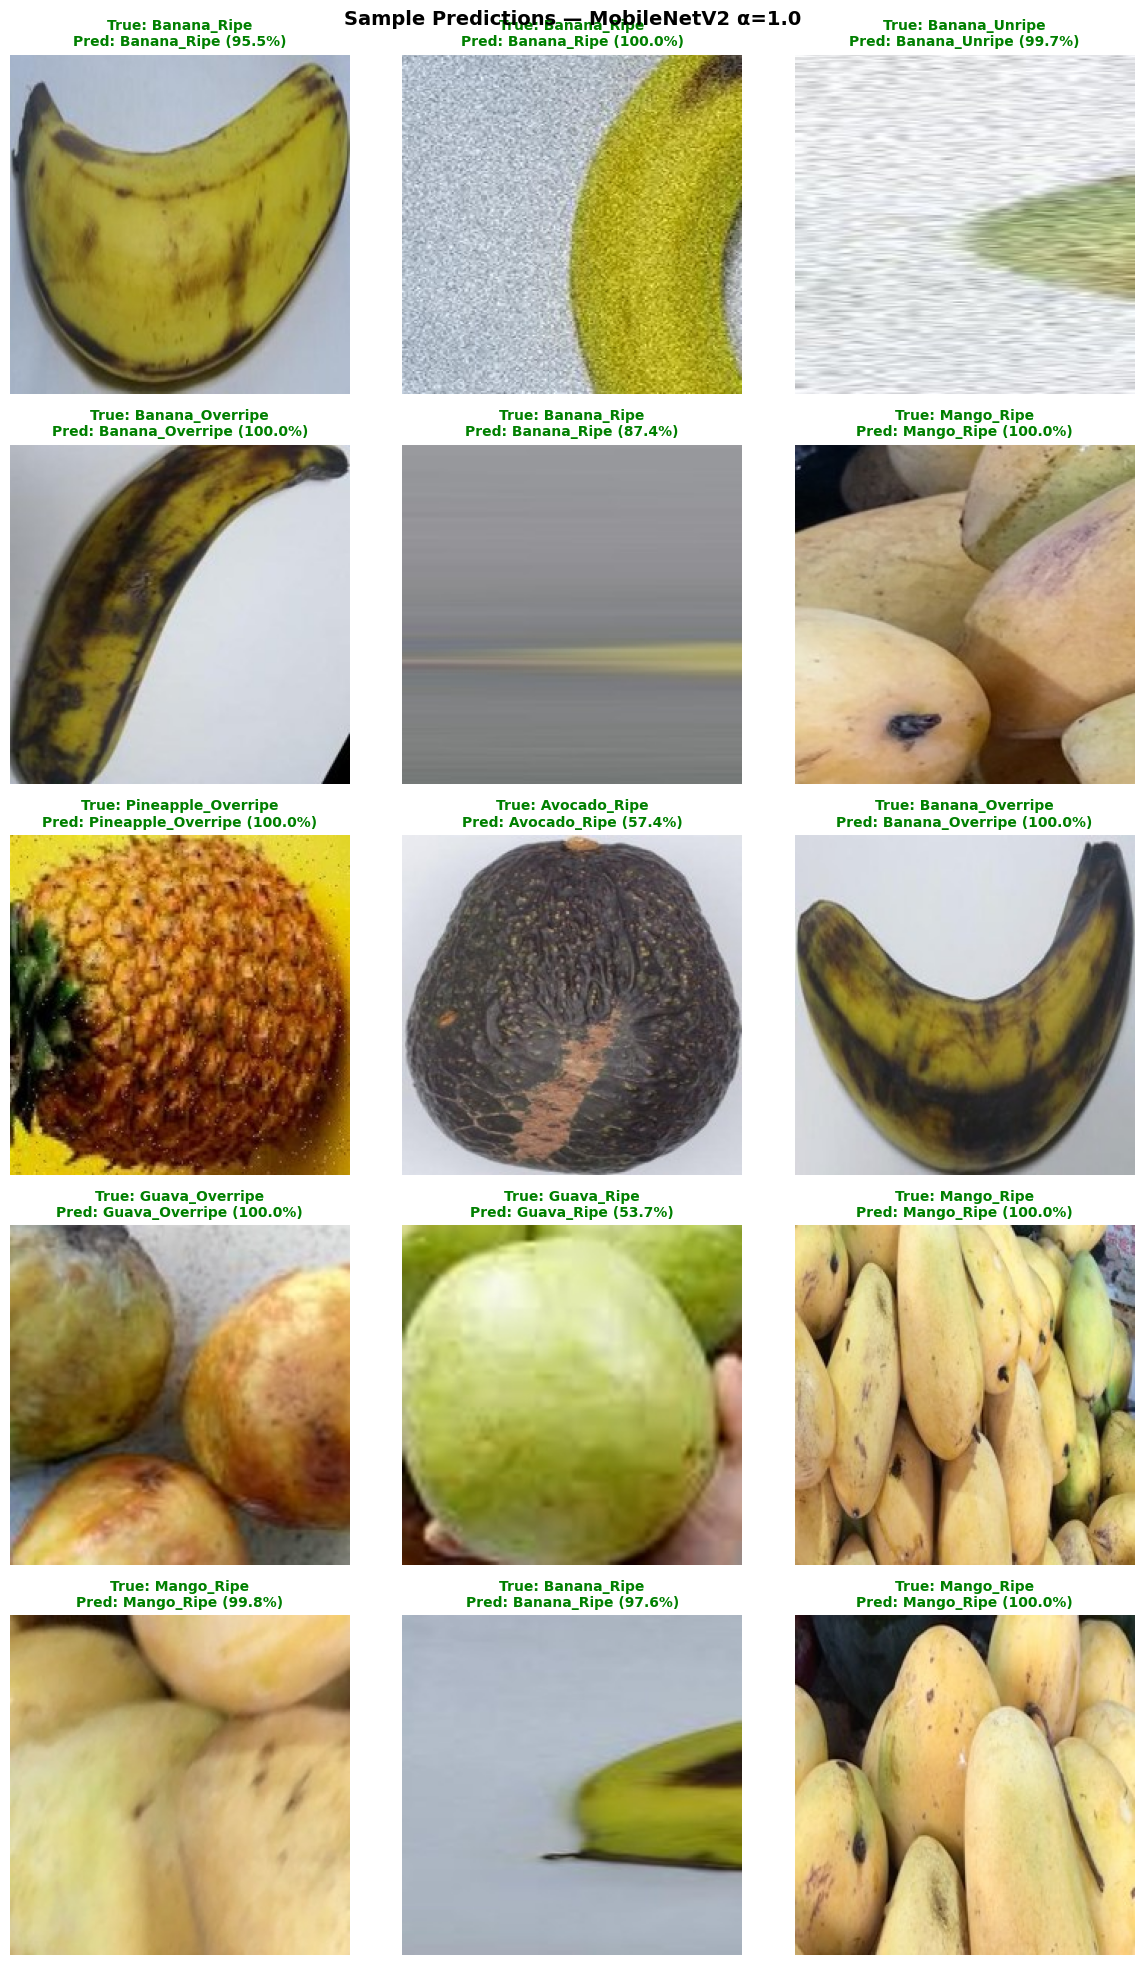

✅ Grid saved → /content/mobilenet_sample_predictions.png


In [ ]:
def visualise_mobilenet_predictions_grid(test_dir, model, class_names, n_samples=15):
    """
    Runs inference on random test images using MobileNetV2 and displays a grid.
    Colors the text GREEN if correct, RED if incorrect.
    """
    all_imgs = glob.glob(f"{test_dir}/**/*.jpg", recursive=True) + \
               glob.glob(f"{test_dir}/**/*.png", recursive=True)

    if not all_imgs:
        print("No test images found!")
        return

    sample = random.sample(all_imgs, min(n_samples, len(all_imgs)))

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i, img_path in enumerate(sample):
        true_label = Path(img_path).parent.name

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

        arr = np.expand_dims(img_resized / 255.0, axis=0)

        probs = model.predict(arr, verbose=0)[0]
        pred_idx = np.argmax(probs)
        pred_label = class_names[pred_idx]
        confidence = probs[pred_idx] * 100

        # Display the image
        axes[i].imshow(img_rgb)

        # Set title color: Green = Correct, Red = Wrong
        color = 'green' if true_label == pred_label else 'red'
        title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"

        axes[i].set_title(title, fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Sample Predictions — MobileNetV2 α={ALPHA}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/mobilenet_sample_predictions.png', dpi=150)
    plt.show()

    print(f"✅ Grid saved → /content/mobilenet_sample_predictions.png")

# Execute the function on the test dataset
visualise_mobilenet_predictions_grid(
    test_dir=f"{CLF_DIR}/test",
    model=model,
    class_names=CLASS_NAMES,
    n_samples=15
)